In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
print(df.shape)
df.head()

(594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [2]:
print(df.columns.tolist())
print(df.shape)

['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
(594194, 21)


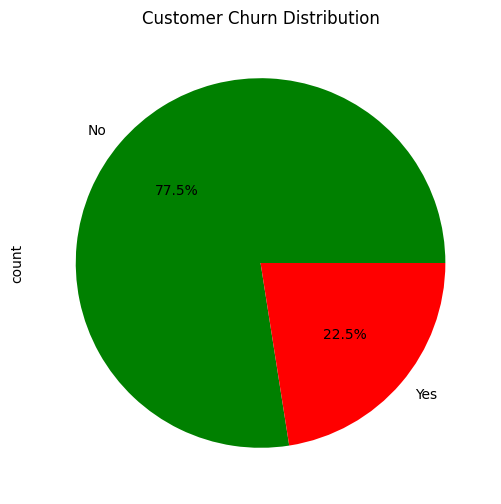

In [3]:
# Churn distribution
plt.figure(figsize=(8,6))
df['Churn'].value_counts().plot(kind='pie',
                                autopct='%1.1f%%',
                                colors=['green', 'red'])
plt.title('Customer Churn Distribution')
plt.show()

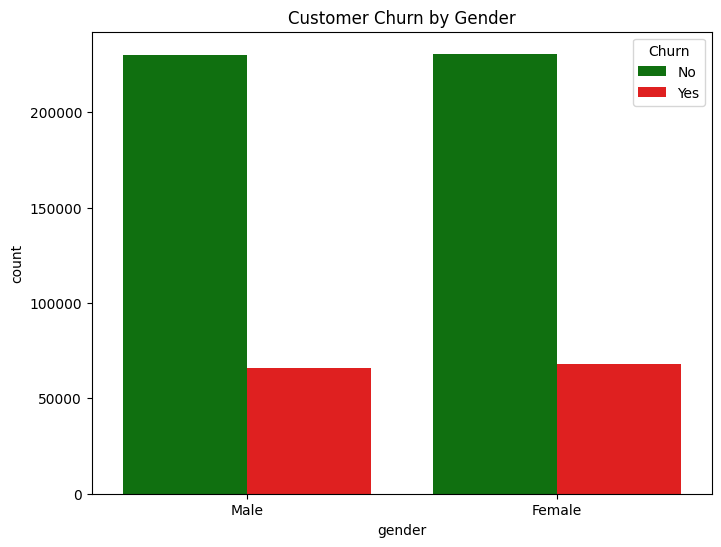

In [4]:
# Churn by Gender
plt.figure(figsize=(8,6))
sns.countplot(x='gender', hue='Churn', data=df, palette=['green', 'red'])
plt.title('Customer Churn by Gender')
plt.show()

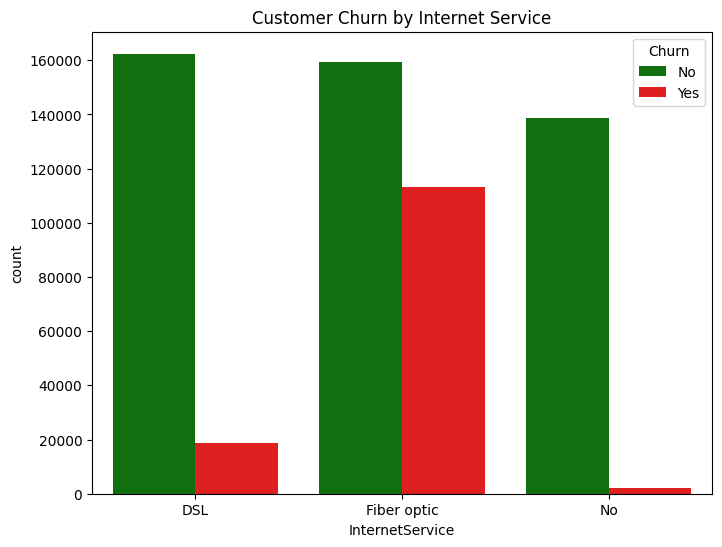

In [5]:
# Churn by Internet Service
plt.figure(figsize=(8,6))
sns.countplot(x='InternetService', hue='Churn', data=df, palette=['green', 'red'])
plt.title('Customer Churn by Internet Service')
plt.show()

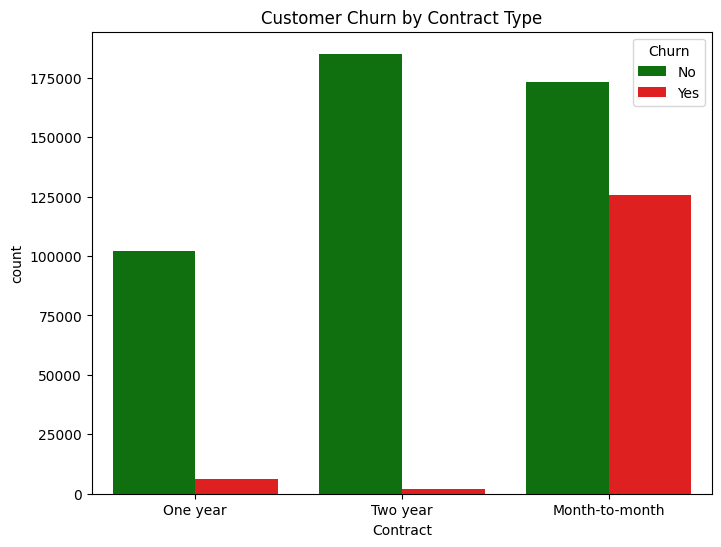

In [6]:
# Churn by Contract Type
plt.figure(figsize=(8,6))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['green', 'red'])
plt.title('Customer Churn by Contract Type')
plt.show()

In [7]:
# Prepare data for ML
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_ml = df.copy()

# Encode categorical columns
for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop(['Churn', 'id'], axis=1)
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 85.3 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


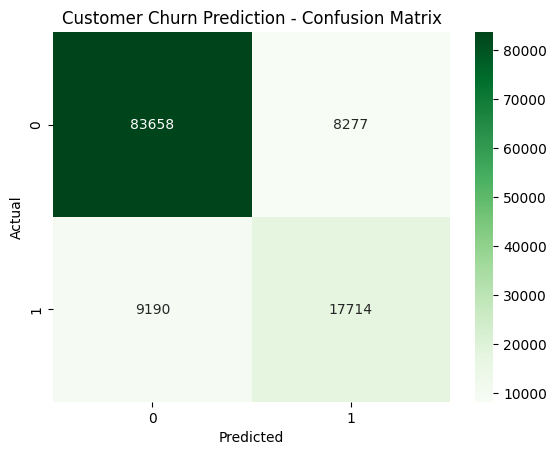

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Customer Churn Prediction - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()